# Crisis Prediction Pipeline
كود واحد شامل: تحميل الموديل، تجهيز بيانات التوقع، correlation، heatmap، feature importance، والتوقع النهائي مع أهم عمود مؤثر لكل صف (SHAP).


In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt


## Config - المسارات والأعمدة

In [14]:
import os

PREDICTION_DATA_PATH = r"D:\project\data sets\DATA FOR PREDICT\economic_indicators_2000_2025_with_fedfunds.csv"
MODEL_PATH = r"D:\project\code\code finale\best model\final model best\xgboost model best\best_model_xgb_optimization.joblib"
TRAINING_DATA_PATH = r"D:\project\data sets\econmic crisis data for train\final data set\global_crisis_new.csv"  # عشان نبني منها نفس الـ imputer

MODEL_FEATURES = [
    "year", "inflation", "gdp_growth", "unemployment", "fed_funds_rate",
    "interest_rate", "exchange_rate", "foreign_reserves", "current_account_gdp",
    "inflation_change", "gdp_growth_change",
]

OUTPUT_DIR = r"D:\project\data sets\predicted results csv\new_best"
IMAGES_DIR = r"D:\project\code\code finale\best model\final model best\xgboost model best\photos"
# بيتأكد إن الفولدرات دي موجودة فعلاً، ولو مش موجودة بيعملها - عشان الحفظ ميفشلش
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)

OUTPUT_CSV_PATH = os.path.join(OUTPUT_DIR, "crisis_predictions_full.csv")
HEATMAP_PATH = os.path.join(IMAGES_DIR, "correlation_heatmap.png")
FEATURE_IMPORTANCE_PATH = os.path.join(IMAGES_DIR, "feature_importance.png")


## 2) تجهيز بيانات التوقع
نفس خطواتك بالظبط: حذف سنين 2000-2015، حذف `government_debt_gdp`، إضافة `inflation_change`/`gdp_growth_change`، fill بالـ imputer المحفوظ (transform بس مش fit جديد)، وإبقاء `iso3` زي ما هي (للعرض بس).

In [ ]:
def load_and_prepare_prediction_data():
    df = pd.read_csv(PREDICTION_DATA_PATH)

    # 1) رتب الأول
    df = df.sort_values(["iso3", "year"]).reset_index(drop=True)

    # 2) احسب الـ diff من التاريخ الكامل (يشمل 2015 وقبلها لو موجودة في الملف)
    df["inflation_change"] = df.groupby("iso3")["inflation"].diff()
    df["gdp_growth_change"] = df.groupby("iso3")["gdp_growth"].diff()

    # 3) دلوقتي بس فلتر السنين اللي عايز تتنبأ عليها
    df = df[df["year"] > 2015].reset_index(drop=True)

    df.drop(["government_debt_gdp"], axis=1, inplace=True)
    df["iso3"] = df["iso3"].fillna("GRP")

    return df

## 3) Correlation + Heatmap

In [16]:
def plot_correlation_heatmap(df, features, save_path=HEATMAP_PATH):
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix - Prediction Data")
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)   # بتتحفظ كصورة كمان
    plt.show()                        # وبتظهر جوه الكود نفسه
    print(f"heatmap saved -> {save_path}")


## 4) Feature Importance (جدول + رسمة)

In [17]:
def compute_feature_importance(rf_model, features, save_path=FEATURE_IMPORTANCE_PATH):
    importances = rf_model.feature_importances_
    fi_df = pd.DataFrame({"Feature": features, "Importance": importances})
    fi_df["Importance_%"] = (fi_df["Importance"] * 100).round(2)
    fi_df = fi_df.sort_values("Importance", ascending=False).reset_index(drop=True)

    indices = np.argsort(importances)
    plt.figure(figsize=(8, 5))
    plt.barh(range(len(indices)), importances[indices], align="center")
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.title("Feature Importances - Crisis Prediction Model")
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)   # بتتحفظ كصورة كمان
    plt.show()                        # وبتظهر جوه الكود نفسه
    print(f"feature importance plot saved -> {save_path}")

    return fi_df


## 5) التوقع + أهم عمود أثر في القرار لكل صف (SHAP)
مش feature importance عام بس، لكن لكل صف/دولة/سنة على حدة - أنهي عمود كان السبب الأكبر في قرار الموديل ليها تحديدًا.

In [18]:
# ============================================================
# شرح كامل لدالة predict_with_top_driver
# ============================================================
#
# الهدف من الدالة:
# -----------------
# مش بس نطلع توقع "أزمة ولا لأ"، لكن كمان نعرف لكل دولة/سنة على
# حدة: إيه أكتر عمود اقتصادي أثر في قرار الموديل بالنسبة لها
# تحديدًا (مش نفس الترتيب العام لكل الداتا، لكن حسب ظروف كل
# صف لوحده).
#
#
# def predict_with_top_driver(df, model, rf_model, features):
#     import shap
# --------------------------------------------------------------
# بنستورد مكتبة shap جوه الدالة نفسها (مش فوق مع باقي الاستيرادات)
# عشان لو حد شغل باقي الكود من غير ما يكون محتاج الجزء ده، ميحصلش
# error لو المكتبة مش متثبتة عنده أصلاً.
#
#
#     X_new = df[features]
# --------------------------------------------------------------
# بناخد بس الأعمدة اللي الموديل اتدرب عليها بالظبط (بنفس الترتيب)
# من الـ DataFrame الكبير، لأن أي عمود زيادة أو ترتيب مختلف
# ممكن يخلي الموديل يرفض يشتغل أو يديك نتيجة غلط.
#
#
#     crisis_probability = model.predict_proba(X_new)[:, 1]
# --------------------------------------------------------------
# predict_proba() بترجع احتمالين لكل صف: احتمال "مفيش أزمة"
# (كلاس 0) واحتمال "فيه أزمة" (كلاس 1)، في عمودين جنب بعض.
# الـ [:, 1] معناها "خد العمود التاني بس" - يعني احتمال حدوث
# الأزمة تحديدًا (كلاس 1)، وده رقم بين 0 و1 لكل صف.
#
#
#     explainer = shap.TreeExplainer(rf_model)
#     shap_values = explainer.shap_values(X_new)
# --------------------------------------------------------------
# TreeExplainer هو أداة SHAP المخصصة لموديلات الأشجار (زي
# Random Forest). هي بتحلل كل شجرة جوه الموديل وبتحسب "مساهمة"
# كل عمود في تحويل التوقع من "المتوسط العام لكل الداتا" للتوقع
# الخاص بالصف ده تحديدًا.
#
# يعني لو الاحتمال العام (لكل الداتا) هو 25%، وطلع احتمال
# زيمبابوي 89%، الفرق ده (64%) بيتقسم على الأعمدة كلها حسب
# مساهمة كل واحد فيهم - وده اللي shap_values بيرجعه لكل صف
# ولكل عمود.
#
#
#     if isinstance(shap_values, list):
#         shap_for_crisis = shap_values[1]
#     elif shap_values.ndim == 3:
#         shap_for_crisis = shap_values[:, :, 1]
#     else:
#         shap_for_crisis = shap_values
# --------------------------------------------------------------
# مشكلة تقنية بسيطة: نسخ مختلفة من مكتبة shap بترجع شكل الناتج
# بطريقة مختلفة شوية لما يكون فيه 2 كلاس (0 و1):
#   - أحيانًا بترجع "list" فيها عنصرين، عنصر لكل كلاس
#     (shap_values[1] = بتاع كلاس الأزمة)
#   - أحيانًا بترجع array واحد لكن بـ 3 أبعاد
#     (صفوف × أعمدة × كلاسات)، فبناخد الكلاس التاني بس [:, :, 1]
#   - أحيانًا بترجع array بسيط لو الموديل شغال على كلاس واحد بس
# الشرط ده بس بيتأكد إننا ماسكين الشكل الصح مهما كانت نسخة
# المكتبة، عشان الكود يفضل شغال حتى لو تحدثت shap.
#
#
#     top_driver_idx = np.argmax(np.abs(shap_for_crisis), axis=1)
#     top_driver_feature = [features[i] for i in top_driver_idx]
# --------------------------------------------------------------
# لكل صف، بناخد القيمة المطلقة (abs) لتأثير كل عمود - لأن عمود
# ممكن "يقلل" الاحتمال (تأثير سالب) وده برضه "تأثير قوي" حتى لو
# مش بيزود الاحتمال. بعدين argmax بيجيب "index" العمود صاحب أكبر
# تأثير (سواء موجب أو سالب) لكل صف. وبعدين بنحول الـ index ده
# لاسم العمود الحقيقي من قائمة features.
#
# مثال: لو زيمبابوي كان معاها inflation=557%، وده كان أكبر رقم
# أثر على قرار الموديل ليها بالذات، هيطلع "inflation" كأهم عمود
# مؤثر في السطر بتاعها هي تحديدًا.
#
#
#     df = df.copy()
# --------------------------------------------------------------
# بناخد نسخة من الـ DataFrame الأصلي قبل ما نضيف عليه أعمدة
# جديدة، عشان منعملش تعديل مباشر (in-place) على الـ df اللي
# جاي من برا الدالة، ونتجنب أي تأثير جانبي غير متوقع على البيانات
# الأصلية في أي مكان تاني في الكود.
#
#
#     df["crisis_probability"] = (crisis_probability * 100).round(2)
# --------------------------------------------------------------
# بنحول الاحتمال من رقم عشري (0.89) لنسبة مئوية (89.00) عشان
# يكون أوضح للعرض، ونقرّبها لـ 2 خانة عشرية بس.
#
#
#     df["crisis_next_12m"] = np.where(crisis_probability >= 0.5, 1, 0)
# --------------------------------------------------------------
# بنحول الاحتمال لقرار نهائي (0 أو 1): لو الاحتمال 50% أو أكتر
# نحطه 1 (متوقع تحصل أزمة)، لو أقل نحطه 0 (مش متوقع). الـ 0.5
# هنا هو الـ "threshold" الافتراضي القياسي في مشاكل التصنيف.
#
#
#     df["top_influencing_feature"] = top_driver_feature
# --------------------------------------------------------------
# بنضيف العمود الجديد اللي بيقول لكل صف: "إيه أهم سبب اقتصادي
# وراء القرار ده تحديدًا" - ده بيدي شفافية عن ليه الموديل قال
# كده، مش بس رقم احتمال من غير تفسير.
#
#
#     return df
# --------------------------------------------------------------
# بيرجع الـ DataFrame كامل، ومعاه دلوقتي 3 أعمدة جديدة:
# crisis_probability, crisis_next_12m, top_influencing_feature
# ============================================================

In [19]:
# الـ Imputer موجود داخل الـ Pipeline المحفوظة مع الموديل.
# لذلك لا نعيد بناء Imputer ولا نعمل fit أو transform يدوي هنا.
# سنمرر بيانات التوقع الخام إلى Pipeline، وهي ستطبق نفس Median Imputer
# الذي تم تدريبه على بيانات التدريب وقت بناء الموديل.

## 1) تجهيز الـ Imputer
نفس الـ median اللي الموديل اتدرب عليها - بنعيد بناءه من `global_crisis_new.csv` بنفس الـ train_test_split بالظبط (`random_state=42`)، عشان القيم اللي هنملى بيها بيانات التوقع تكون **نفس** القيم اللي الموديل شافها وقت التدريب، مش أرقام جديدة محسوبة من بيانات التوقع نفسها (وده بيمنع أي عدم اتساق صامت).

In [20]:
# # ============================================================
# # دالة التنبؤ مع تحديد أهم Feature أثرت في كل تنبؤ
# # ============================================================

# def predict_with_top_driver(df, model, rf_model, features):
#     # استدعاء مكتبة SHAP لاستخراج تأثير كل Feature على قرار الموديل.
#     # يتم استدعاؤها داخل الدالة حتى نستخدمها فقط عند الحاجة إلى التفسير.
#     import shap

#     # اختيار Features التي استخدمها الموديل فقط من بيانات التوقع.
#     # البيانات هنا ما زالت في صورتها الأصلية وقد تحتوي على Missing Values.
#     X_new = df[features]

#     # حساب احتمال حدوث الأزمة، أي احتمال Class 1.
#     # الـ Pipeline المحفوظة ستطبق الـ Imputer الموجود بداخلها تلقائيًا
#     # قبل تمرير البيانات إلى Random Forest.
#     # [:, 1] تعني اختيار احتمال Class 1 من احتمالي Class 0 وClass 1.
#     crisis_probability = model.predict_proba(X_new)[:, 1]

#     # نحتاج إلى تطبيق نفس الـ Imputer الموجود داخل Pipeline
#     # قبل استخدام SHAP؛ لأننا نستخدم clf مباشرة وليس الـ Pipeline كاملة.
#     # transform فقط يعني استخدام Median التي تعلمها Imputer أثناء التدريب،
#     # بدون عمل fit جديد على بيانات التوقع.
#     fitted_imputer = model.named_steps["imputer"]
#     X_new_imputed = fitted_imputer.transform(X_new)

#     # إنشاء SHAP Explainer خاص بنموذج Random Forest.
#     # SHAP يوضح مقدار مساهمة كل Feature في قرار الموديل لكل صف.
#     explainer = shap.TreeExplainer(rf_model)
#     shap_values = explainer.shap_values(X_new_imputed)

#     # التعامل مع الأشكال المختلفة التي يمكن أن ترجع بها SHAP القيم:
#     # في بعض الإصدارات ترجع SHAP قائمة منفصلة لكل Class،
#     # وفي إصدارات أخرى ترجع Array تحتوي على Class 0 وClass 1.
#     # نختار دائمًا القيم الخاصة بـ Class 1 لأنها تمثل احتمال الأزمة.
#     if isinstance(shap_values, list):
#         shap_for_crisis = shap_values[1]
#     elif shap_values.ndim == 3:
#         shap_for_crisis = shap_values[:, :, 1]
#     else:
#         shap_for_crisis = shap_values

#     # حساب القيمة المطلقة لتأثير كل Feature.
#     # نستخدم القيمة المطلقة لأننا نهتم بأكبر تأثير سواء كان التأثير
#     # يزيد احتمال الأزمة أو يقلله.
#     top_driver_idx = np.argmax(np.abs(shap_for_crisis), axis=1)

#     # تحويل رقم الـ Feature صاحب أكبر تأثير إلى اسمه الحقيقي.
#     top_driver_feature = [features[i] for i in top_driver_idx]

#     # إنشاء نسخة من DataFrame حتى لا نغير البيانات الأصلية مباشرة.
#     df = df.copy()

#     # إضافة احتمال الأزمة كنسبة مئوية وتقريبه إلى منزلتين عشريتين.
#     df["crisis_probability"] = (crisis_probability * 100).round(2)

#     # تحويل الاحتمال إلى قرار نهائي:
#     # إذا كان احتمال الأزمة 50% أو أكثر، يكون التنبؤ Class 1.
#     # وإذا كان أقل من 50%، يكون التنبؤ Class 0.
#     df["crisis_next_12m"] = np.where(crisis_probability >= 0.5, 1, 0)

#     # إضافة اسم الـ Feature التي كان لها أكبر تأثير على قرار كل صف.
#     df["top_influencing_feature"] = top_driver_feature

#     # إرجاع DataFrame الأصلي مع أعمدة الاحتمال والتنبؤ
#     # وأهم Feature مؤثرة في القرار.
#     return df


In [21]:
# # ============================================================
# # توحيد شكل نتائج SHAP واختيار تأثير Class 1
# # ============================================================
# # مكتبة SHAP قد ترجع النتائج بأشكال مختلفة حسب إصدار المكتبة
# # ونوع الموديل المستخدم، لذلك نتحقق من شكل shap_values أولًا.

# if isinstance(shap_values, list):
#     # إذا كانت النتائج List، فكل عنصر يمثل Class مختلفة.
#     # shap_values[1] يختار تأثير جميع Features على Class 1،
#     # وهي الفئة التي تمثل حدوث الأزمة.
#     shap_for_crisis = shap_values[1]

# elif shap_values.ndim == 3:
#     # إذا كانت النتائج Array ثلاثية الأبعاد،
#     # فإن البعد الأول يمثل الصفوف، والثاني يمثل Features،
#     # والثالث يمثل Classes.
#     # [:, :, 1] تعني اختيار كل الصفوف وكل Features وClass 1 فقط.
#     shap_for_crisis = shap_values[:, :, 1]

# else:
#     # إذا كانت النتائج Array ثنائية الأبعاد،
#     # نستخدمها كما هي لأنها تحتوي بالفعل على تأثير Features
#     # لكل صف، ولا تحتاج إلى اختيار Class إضافية.
#     shap_for_crisis = shap_values

# # ============================================================
# # إنشاء نسخة مستقلة من DataFrame
# # ============================================================
# # ننشئ نسخة مستقلة من df حتى لا نعدل DataFrame الأصلي مباشرة.
# # بعد ذلك نضيف إلى النسخة الجديدة أعمدة احتمال الأزمة،
# # والتنبؤ النهائي، وأهم Feature أثرت في قرار كل صف.
# df = df.copy()


In [22]:
def predict_with_top_driver(df, model, rf_model, features):
    import shap

    # نمرر البيانات الخام إلى الـ Pipeline.
    # الـ Pipeline ستطبق الـ Median Imputer تلقائيًا قبل التنبؤ.
    X_new = df[features]

     #:    # كل الصفوف
     # العمود رقم 1، أي العمود الثاني
# [:, 1] تعني اختيار جميع الصفوف من العمود الثاني.
# لأن العد في Python يبدأ من الصفر، فالعمود رقم 1 يمثل Class 1،
    # احتمال حدوث الأزمة (كلاس 1)
    
    # التعديل الجديد: ملف الموديل المحفوظ هو RandomizedSearchCV، وليس Pipeline مباشرة.
    # لذلك نستخدم best_estimator_ عند وجوده حتى تعمل predict_proba على الـ Pipeline الفائزة.
    fitted_pipeline = model.best_estimator_ if hasattr(model, "best_estimator_") else model
    crisis_probability = fitted_pipeline.predict_proba(X_new)[:, 1]


    # SHAP يحتاج البيانات بعد تطبيق الـ Imputer، لأننا نستخدم clf مباشرة.
    # التعديل الجديد: نقرأ الـ Imputer من الـ Pipeline الفائزة بعد فك غلاف RandomizedSearchCV.
    fitted_imputer = fitted_pipeline.named_steps["imputer"]
    X_new_imputed = fitted_imputer.transform(X_new)

    # SHAP: بيوضح لكل صف كل عمود أثر بقد ايه في قرار الموديل تحديدًا
    # التعديل الجديد: rf_model هنا هو الـ XGBoost classifier المحفوظ داخل خطوة clf؛
    # TreeExplainer مناسب لموديلات الأشجار ومنها XGBoost.
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_new_imputed)

    # لو الموديل عنده 2 كلاس، shap_values بترجع array شكلها (n_samples, n_features, n_classes)
    if isinstance(shap_values, list):
        shap_for_crisis = shap_values[1]
    elif shap_values.ndim == 3:
        shap_for_crisis = shap_values[:, :, 1]
    else:
        shap_for_crisis = shap_values

    # أهم عمود لكل صف = العمود صاحب أكبر تأثير (بالقيمة المطلقة) على قرار "الأزمة"
    top_driver_idx = np.argmax(np.abs(shap_for_crisis), axis=1)
    top_driver_feature = [features[i] for i in top_driver_idx]

    df = df.copy()

    # التعديل الجديد: الـ Pipeline كانت تعوّض القيم الناقصة داخليًا أثناء predict فقط،
    # لكن DataFrame الناتج كان يحتفظ بالـ nulls الأصلية عند العرض والحفظ.
    # لذلك نكتب هنا القيم بعد transform بنفس الـ fitted imputer داخل الـ Pipeline،
    # حتى تكون أعمدة الـ features في النتائج متسقة مع البيانات التي رآها XGBoost.
    df.loc[:, features] = X_new_imputed

    df["crisis_probability"] = (crisis_probability * 100).round(2)
    df["crisis_next_12m"] = np.where(crisis_probability >= 0.5, 1, 0)
    df["top_influencing_feature"] = top_driver_feature

    return df


## main() - بيشغل كل حاجة بالترتيب

In [23]:
def main(display_n=20):
    """
    display_n: عدد الصفوف اللي هتتعرض في الشاشة (مرتبة بالأعلى احتمال أزمة).
    كل التوقعات (مش بس اللي هتتعرض) بتتحفظ كاملة في CSV.
    """
    print("1) Loading trained model with its fitted Pipeline...")
    loaded_model = joblib.load(MODEL_PATH)

    print("2) Loading & preparing prediction data...")
    df = load_and_prepare_prediction_data()

    print("3) Correlation & heatmap...")
    plot_correlation_heatmap(df, MODEL_FEATURES)

    # التعديل الجديد: الموديل المحفوظ من بحث XGBoost هو RandomizedSearchCV،
    # لذلك نفك الغلاف ونستخرج الـ Pipeline الفائزة قبل الوصول إلى خطوة clf.
    fitted_pipeline = loaded_model.best_estimator_ if hasattr(loaded_model, "best_estimator_") else loaded_model
    rf_model = fitted_pipeline.named_steps["clf"]
    print("Model loaded successfully!")

    print("3) Feature importance...")
    fi_df = compute_feature_importance(rf_model, MODEL_FEATURES)
    print(fi_df.to_string(index=False))

    print("4) Predicting on ALL rows + top influencing feature per row...")
    result_full = predict_with_top_driver(df, loaded_model, rf_model, MODEL_FEATURES)

    # الأعمدة النهائية: هوية الدولة + كل الإحصائيات الاقتصادية اللي بيتنبأ منها + التوقع
    display_cols = (
        ["iso3", "country", "year"]
        + MODEL_FEATURES[1:]  # كل الأعمدة الاقتصادية عدا year
        + ["crisis_probability", "crisis_next_12m", "top_influencing_feature"]
    )
    result_full = result_full[display_cols]
    result_full_sorted = result_full.sort_values("crisis_probability", ascending=False).reset_index(drop=True)

    # حفظ كل التوقعات (بدون أي قص) في CSV
    result_full_sorted.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"\nكل التوقعات ({len(result_full_sorted)} صف) اتحفظت في: {OUTPUT_CSV_PATH}")

    # عرض أول display_n صف بس على الشاشة
    print(f"\n===== أعلى {display_n} حالة احتمال أزمة =====")
    print(result_full_sorted.head(display_n).to_string(index=False))

    return result_full_sorted


## تشغيل الكود
غيّر الرقم في `display_n` لو عايز تعرض عدد صفوف مختلف على الشاشة.

1) Loading trained model with its fitted Pipeline...
2) Loading & preparing prediction data...
3) Correlation & heatmap...


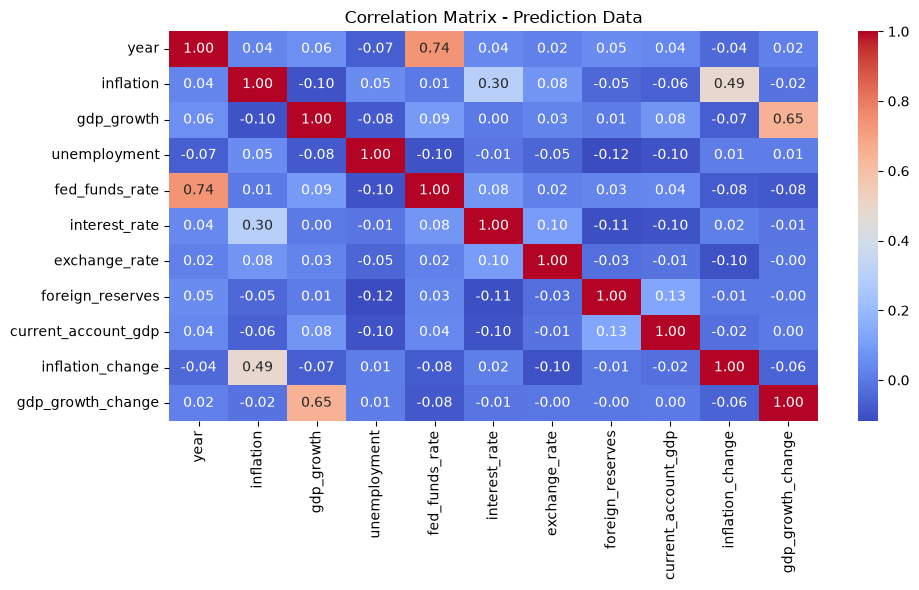

heatmap saved -> D:\project\code\code finale\best model\final model best\xgboost model best\photos\correlation_heatmap.png
Model loaded successfully!
3) Feature importance...


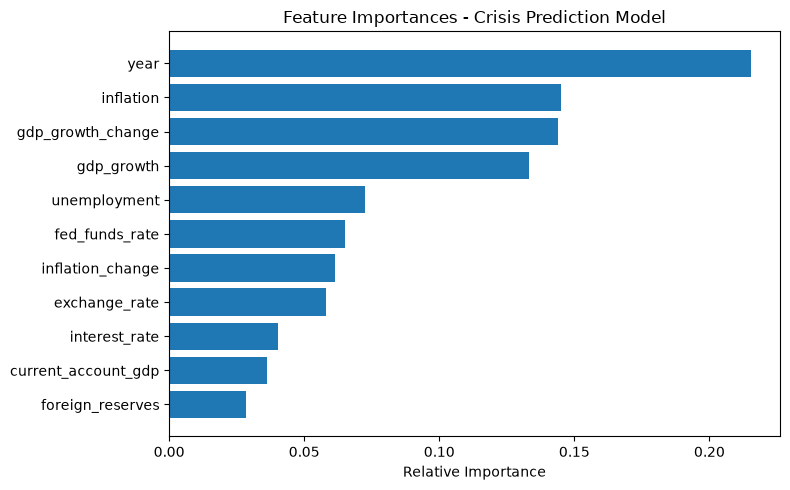

feature importance plot saved -> D:\project\code\code finale\best model\final model best\xgboost model best\photos\feature_importance.png
            Feature  Importance  Importance_%
               year    0.215361     21.540001
          inflation    0.144977     14.500000
  gdp_growth_change    0.144071     14.410000
         gdp_growth    0.133227     13.320000
       unemployment    0.072524      7.250000
     fed_funds_rate    0.065041      6.500000
   inflation_change    0.061489      6.150000
      exchange_rate    0.058075      5.810000
      interest_rate    0.040465      4.050000
current_account_gdp    0.036158      3.620000
   foreign_reserves    0.028612      2.860000
4) Predicting on ALL rows + top influencing feature per row...

كل التوقعات (2650 صف) اتحفظت في: D:\project\data sets\predicted results csv\new_best\crisis_predictions_full.csv

===== أعلى 20 حالة احتمال أزمة =====
iso3            country  year  inflation  gdp_growth  unemployment  fed_funds_rate  interest_ra

In [24]:
predictions_df = main(display_n=20)
#الاعمده ةالي ارتباطها يعتبر كبير مع بعضاكبر من 0.5  ده معناها ان التغير علي ده بيحصل علي ده في نفس اللحظه 
#وده مش عيب في حد ذاته ده منطقي جدا 
# منطقي اقتصاديًا: البنك الفيدرالي الأمريكي رفع الفائدة بشكل كبير من 2022 إلى 2023،
# من مستويات قريبة من الصفر إلى حوالي 5%.
#
# لذلك من الطبيعي أن يكون هناك ارتباط بين السنة وسعر الفائدة خلال هذه الفترة.
#
# هذا لا يعني أن المعلومتين مكررتان؛ فكل واحدة تحمل معنى مختلف:
# السنة توضح "متى حدث الأمر"، بينما سعر الفائدة يوضح "الفائدة كام كانت".
#
# لكنهما ارتفعا معًا بشكل واضح بسبب السياسة النقدية خلال هذه الفترة.